<a href="https://www.kaggle.com/code/lalit7881/student-burnout-mental-health?scriptVersionId=307693367" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ayeshasiddiqa123/student-health/student_mental_health_burnout_1M.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ayeshasiddiqa123/student-health/student_mental_health_burnout_1M.csv")

In [3]:
df.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [4]:
df.tail()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
999995,22,Female,3,5.784771,4.922653,79.292283,2.033221,1.238058,0.000000,8.214062,4.404825,9.013047,1.000000,1.664220,5.374860,4.875184,0.000000,8.815294,Low,0.000000
999996,20,Male,1,3.795347,4.706976,70.718819,4.144918,2.768193,1.405596,6.701671,2.664749,8.678769,2.641657,2.923180,5.100452,5.495558,1.166516,7.089896,Low,0.000000
999997,24,Female,3,8.814898,8.750319,79.121184,4.715533,4.138000,1.931592,6.569535,4.219224,4.881412,5.224459,3.855320,2.290888,6.792472,1.997088,6.292909,Low,1.172209
999998,29,Female,4,5.920859,6.678223,69.424255,5.553155,5.681447,1.366879,8.017232,3.634823,5.232852,2.668379,2.951508,5.885972,6.829679,2.731137,5.664240,Low,1.968401
999999,17,Female,2,5.733588,6.061671,58.666123,2.936770,2.533496,0.661940,6.868650,5.501813,2.832691,1.000000,1.000000,5.187394,5.162718,1.342995,7.866661,Low,0.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [6]:
df.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,22.996456,2.500782,5.001727,5.998810,70.999135,4.246462,2.986413,1.274728,6.501713,3.011153,4.999724,5.018766,5.038116,5.002920,5.983287,1.784073,7.023073,1.324896
std,3.742579,1.117749,1.989340,1.548268,5.660073,1.678998,1.509844,1.221273,1.472972,1.463679,1.976536,1.960599,2.157838,1.976426,1.960972,1.664035,1.310698,1.342727
min,17.000000,1.000000,0.000000,1.000000,42.365714,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.309745,0.000000
25%,20.000000,2.000000,3.650644,4.944647,67.180912,3.102593,1.923747,0.005198,5.491047,1.990596,3.650029,3.651138,3.491114,3.656767,4.647065,0.124810,6.141553,0.000000
50%,23.000000,3.000000,4.998222,5.998906,70.999914,4.244029,2.969514,1.047839,6.501938,3.000619,4.999017,5.003518,5.001542,5.001279,5.999517,1.496505,7.074414,1.009531
75%,26.000000,4.000000,6.345532,7.051914,74.820937,5.385464,4.014996,2.086397,7.514642,4.011208,6.349751,6.351386,6.506834,6.354571,7.351578,2.889473,7.962169,2.173661
max,29.000000,4.000000,14.000000,10.000000,97.246309,10.000000,10.000000,8.530800,10.000000,7.000000,10.000000,12.000000,14.000000,10.000000,10.000000,10.000000,10.000000,9.326226


In [7]:
df.dtypes

age                       int64
gender                   object
academic_year             int64
study_hours_per_day     float64
exam_pressure           float64
academic_performance    float64
stress_level            float64
anxiety_score           float64
depression_score        float64
sleep_hours             float64
physical_activity       float64
social_support          float64
screen_time             float64
internet_usage          float64
financial_stress        float64
family_expectation      float64
burnout_score           float64
mental_health_index     float64
risk_level               object
dropout_risk            float64
dtype: object

In [8]:
df.shape

(1000000, 20)

In [9]:
df.columns

Index(['age', 'gender', 'academic_year', 'study_hours_per_day',
       'exam_pressure', 'academic_performance', 'stress_level',
       'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity',
       'social_support', 'screen_time', 'internet_usage', 'financial_stress',
       'family_expectation', 'burnout_score', 'mental_health_index',
       'risk_level', 'dropout_risk'],
      dtype='object')

In [10]:
df.isnull().sum()

age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_score           0
mental_health_index     0
risk_level              0
dropout_risk            0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

age                          13
gender                        3
academic_year                 4
study_hours_per_day      993775
exam_pressure            994553
academic_performance    1000000
stress_level             993869
anxiety_score            973420
depression_score         751049
sleep_hours              980406
physical_activity        973321
social_support           987746
screen_time              976736
internet_usage           968385
financial_stress         987610
family_expectation       975615
burnout_score            769455
mental_health_index      997359
risk_level                    3
dropout_risk             737663
dtype: int64

## EDA

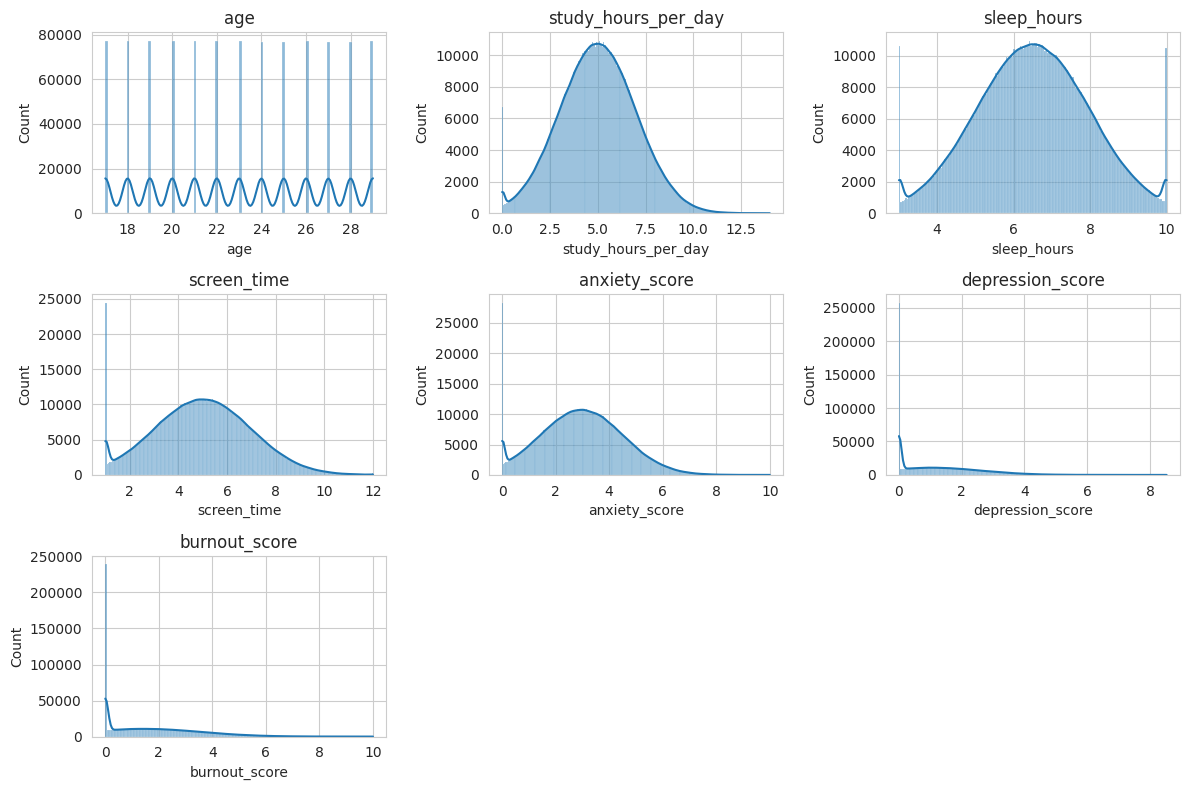

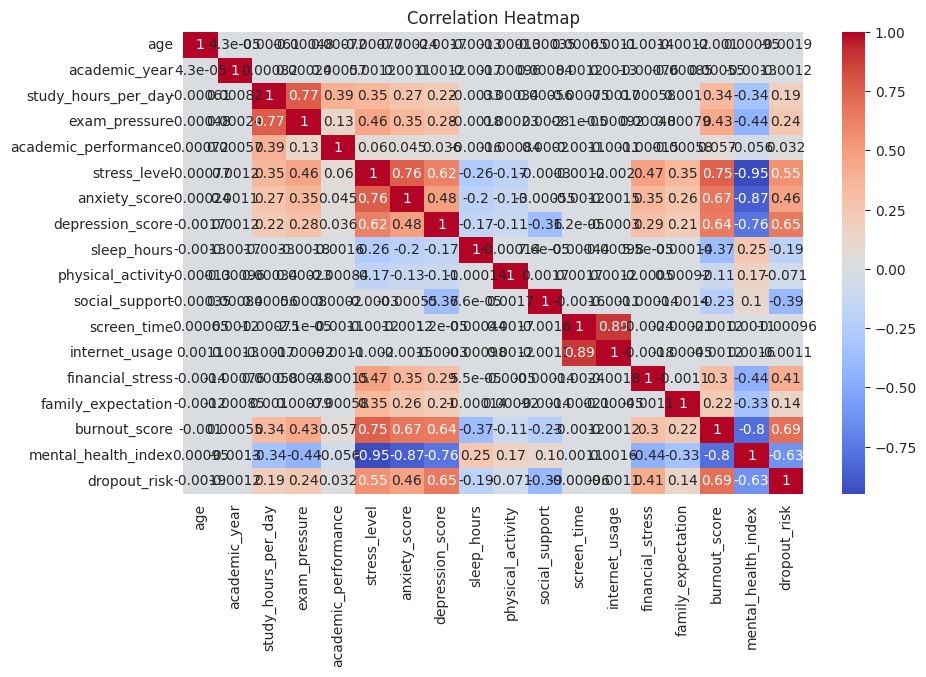

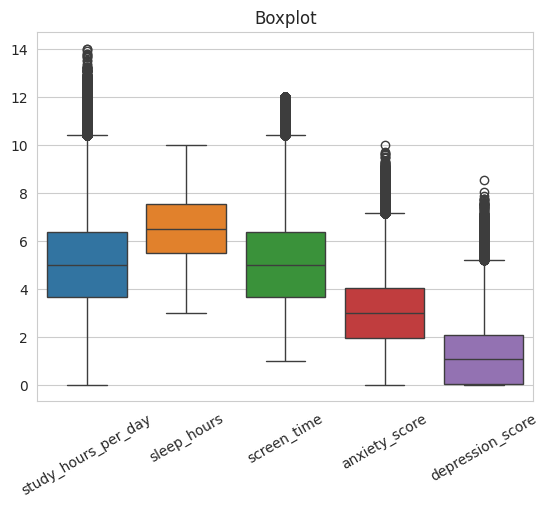

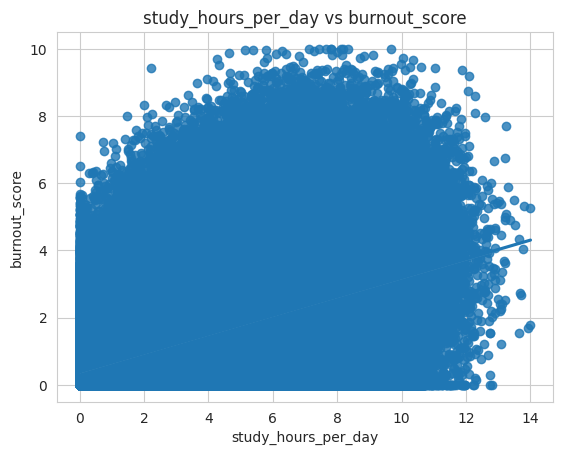

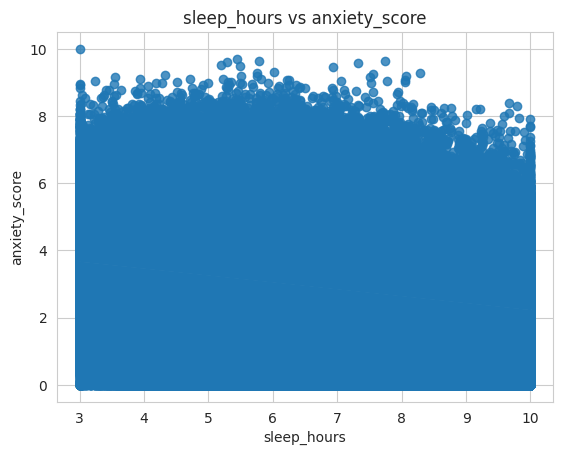

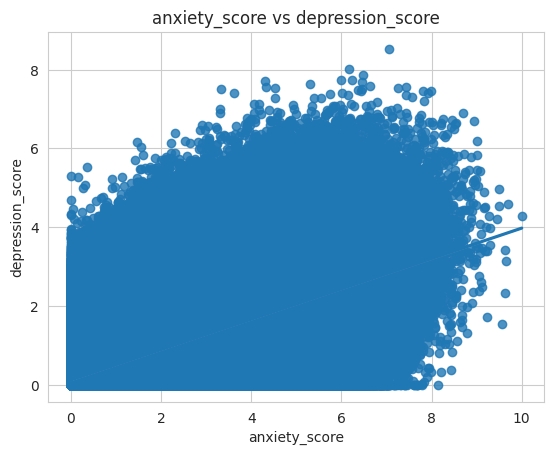

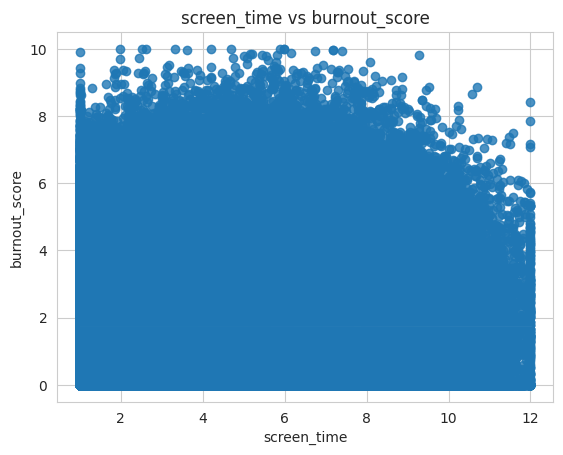

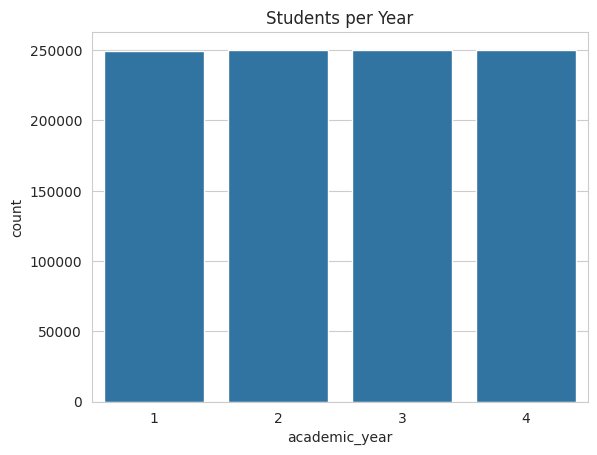

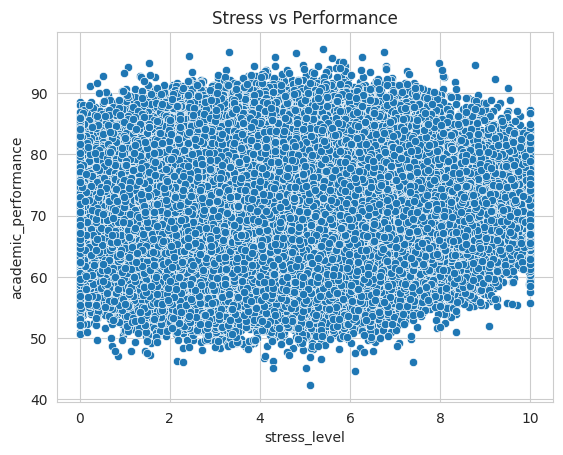

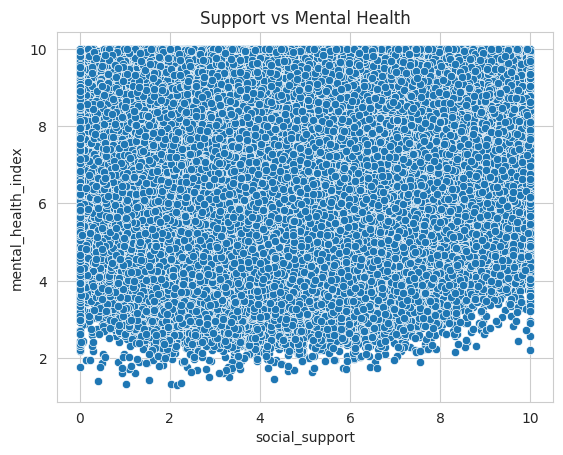

In [13]:
# Clean columns
df.columns = df.columns.str.strip().str.lower()

# Style
sns.set_style("whitegrid")

# ---------------------------
# 1. Distribution Plots
# ---------------------------
cols = [
    'age','study_hours_per_day','sleep_hours','screen_time',
    'anxiety_score','depression_score','burnout_score'
]

plt.figure(figsize=(12,8))
for i, col in enumerate([c for c in cols if c in df.columns]):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# ---------------------------
# 2. Correlation Heatmap
# ---------------------------
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ---------------------------
# 3. Boxplot
# ---------------------------
box_cols = [c for c in [
    'study_hours_per_day','sleep_hours',
    'screen_time','anxiety_score','depression_score'
] if c in df.columns]

if box_cols:
    sns.boxplot(data=df[box_cols])
    plt.xticks(rotation=30)
    plt.title("Boxplot")
    plt.show()

# ---------------------------
# 4. Fast Alternative to Pairplot
# ---------------------------
relations = [
    ('study_hours_per_day','burnout_score'),
    ('sleep_hours','anxiety_score'),
    ('anxiety_score','depression_score'),
    ('screen_time','burnout_score')
]

for x, y in relations:
    if {x, y}.issubset(df.columns):
        sns.regplot(x=x, y=y, data=df)
        plt.title(f"{x} vs {y}")
        plt.show()

# ---------------------------
# 5. Quick Insights Plots
# ---------------------------
if 'academic_year' in df.columns:
    sns.countplot(x='academic_year', data=df)
    plt.title("Students per Year")
    plt.show()

if {'stress_level','academic_performance'}.issubset(df.columns):
    sns.scatterplot(x='stress_level', y='academic_performance', data=df)
    plt.title("Stress vs Performance")
    plt.show()

if {'social_support','mental_health_index'}.issubset(df.columns):
    sns.scatterplot(x='social_support', y='mental_health_index', data=df)
    plt.title("Support vs Mental Health")
    plt.show()

## Feature engineering

In [14]:
print("Unique target values:", np.unique(y))
print("Target distribution:\n", pd.Series(y).value_counts())

Unique target values: ['burnout_score']
Target distribution:
 burnout_score    1
Name: count, dtype: int64


In [15]:
low = df['dropout_risk'].quantile(0.4)
high = df['dropout_risk'].quantile(0.6)

# Create 3 classes → then convert to binary
df['dropout_label'] = 0
df.loc[df['dropout_risk'] >= high, 'dropout_label'] = 1

# Keep only clear classes (remove middle noise)
df = df[(df['dropout_risk'] <= low) | (df['dropout_risk'] >= high)]

# Check distribution
print("Target Distribution:\n", df['dropout_label'].value_counts())

# FINAL CHECK
if df['dropout_label'].nunique() < 2:
    raise ValueError("❌ Still one class — check data")

Target Distribution:
 dropout_label
1    400000
0    400000
Name: count, dtype: int64


Shape: (800000, 21)
   age  gender  academic_year  study_hours_per_day  exam_pressure  \
0   23    Male              2             5.596071       6.487218   
1   20    Male              3             5.597171       5.631481   
3   27    Male              4             4.607208       6.684005   
4   24    Male              4             2.186569       4.010945   
5   29  Female              3             7.697210       8.460408   

   academic_performance  stress_level  anxiety_score  depression_score  \
0             68.411114      4.116950       2.275713          1.986730   
1             67.682159      0.349489       0.000000          0.000000   
3             68.925653      6.778843       4.512425          4.285645   
4             69.141915      1.854595       1.102558          0.000000   
5             68.332246      5.464786       1.720314          2.313338   

   sleep_hours  ...  social_support  screen_time  internet_usage  \
0     6.880545  ...        6.470080     4.993801    

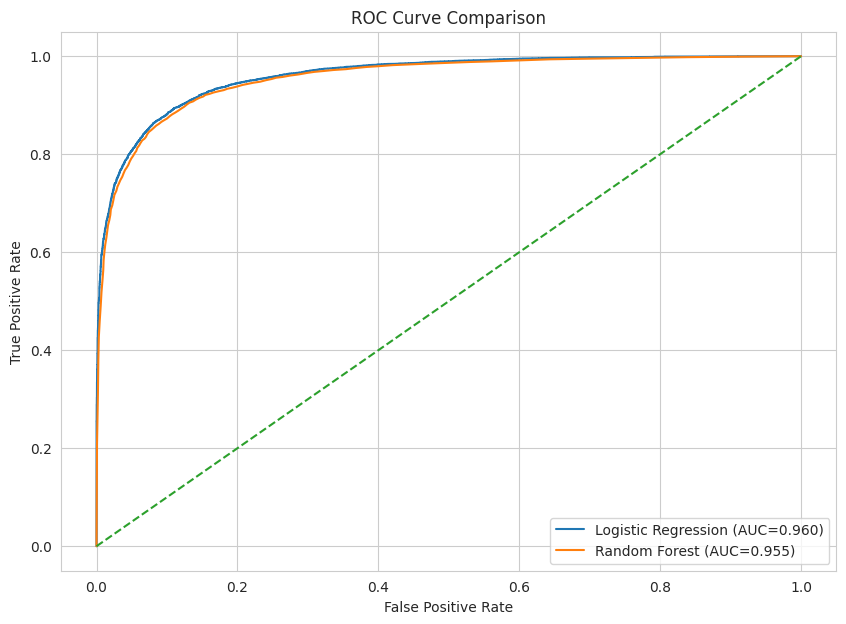

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier



# Clean columns
df.columns = df.columns.str.strip().str.lower()

print("Shape:", df.shape)
print(df.head())



# Use quantile-based split (guaranteed balance)
low = df['dropout_risk'].quantile(0.4)
high = df['dropout_risk'].quantile(0.6)

df['dropout_label'] = 0
df.loc[df['dropout_risk'] >= high, 'dropout_label'] = 1

# Keep only strong classes
df = df[(df['dropout_risk'] <= low) | (df['dropout_risk'] >= high)]

print("\nTarget Distribution:\n", df['dropout_label'].value_counts())

# Safety check
if df['dropout_label'].nunique() < 2:
    raise ValueError("❌ Only one class present!")

# =====================================================
# 5. SAMPLING (SAFE)
# =====================================================
df = df.sample(min(100000, len(df)), random_state=42)

# =====================================================
# 6. FEATURES & TARGET
# =====================================================
X = df.drop(columns=['dropout_risk', 'dropout_label'])
y = df['dropout_label']

# Column types
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# =====================================================
# 7. TRAIN TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# 8. PREPROCESSING
# =====================================================
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# =====================================================
# 9. MODELS
# =====================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# =====================================================
# 10. TRAINING + EVALUATION
# =====================================================
plt.figure(figsize=(10,7))

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob[:,1])
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob[:,1])
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    
    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print("-"*40)

# =====================================================
# 11. FINAL ROC CURVE
# =====================================================
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Thank you..pls upvote!!!!!!!